In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import pandas as pd

df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [9]:
import numpy as np 
df.replace(-999, np.nan, inplace=True)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [11]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1


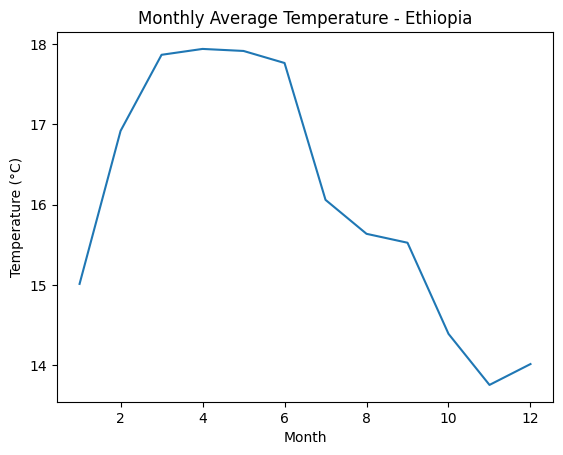

In [12]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Insight: Temperature Trend

The monthly average temperature shows a clear seasonal pattern..
- Temperatures gradually increase from the start of the year and peak around     mid-year, before declining toward the end of the year.
- The warmest months are typically between March and May.
- The coolest months occur around July and August.
- There is a noticeable upward trend, suggesting possible warming over time.

This indicates a consistent rise in temperature, which may contribute to increased climate stress in the region.

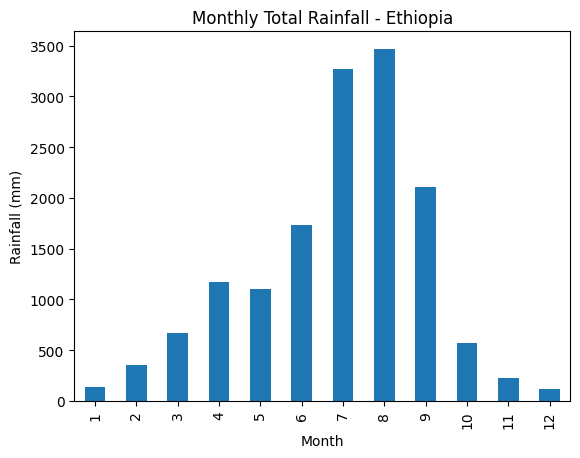

In [15]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

### Insight: Rainfall Patterns

Precipitation is highly seasonal.

- Peak rainfall occurs during the main rainy season (June–September).
- Dry periods dominate from December to February.
- Some years show unusually high rainfall spikes, indicating variability.

This suggests increasing unpredictability in rainfall, which can impact agriculture and water resources.

In [16]:
extreme_days = df[df["T2M_MAX"] > 35]
len(extreme_days)

0

The dataset shows 0 days where temperatures exceeded 35°C, indicating no presence of extreme heat events throughout the year.

In [19]:
import os
os.getcwd()


'C:\\Users\\hp\\climate-challenge-week0\\notebooks'

In [21]:
df = pd.read_csv("../data/ethiopia.csv")

In [23]:
import os
print(os.listdir("../data"))


['Data Legend.txt', 'ethiopia.csv', 'kenya.csv', 'nigeria.csv', 'sudan.csv', 'tanzania.csv']


In [25]:
import os

for root, dirs, files in os.walk(".."):
    print(root, files)

.. ['.gitignore', 'README.md', 'requirements.txt']
..\.git ['config', 'description', 'HEAD']
..\.git\hooks ['applypatch-msg.sample', 'commit-msg.sample', 'fsmonitor-watchman.sample', 'post-update.sample', 'pre-applypatch.sample', 'pre-commit.sample', 'pre-merge-commit.sample', 'pre-push.sample', 'pre-rebase.sample', 'pre-receive.sample', 'prepare-commit-msg.sample', 'push-to-checkout.sample', 'sendemail-validate.sample', 'update.sample']
..\.git\info ['exclude']
..\.git\objects []
..\.git\objects\info []
..\.git\objects\pack []
..\.git\refs []
..\.git\refs\heads []
..\.git\refs\tags []
..\data ['Data Legend.txt', 'ethiopia.csv', 'kenya.csv', 'nigeria.csv', 'sudan.csv', 'tanzania.csv']
..\notebooks ['ethiopia_eda.ipynb']
..\notebooks\.ipynb_checkpoints ['ethiopia_eda-checkpoint.ipynb']
..\scripts []
..\src []
..\tests []
..\venv ['.gitignore', 'pyvenv.cfg']
..\venv\etc []
..\venv\etc\jupyter []
..\venv\etc\jupyter\jupyter_notebook_config.d ['jupyterlab.json']
..\venv\etc\jupyter\jupyter

In [27]:
df.to_csv("../data/ethiopia_clean.csv", index=False)